# **CSC713M (G01) Major Course Output**
### Group: Machine Yearning (Marvin Ivan Mangubat and Jose Carlos Regala)

This is our Jupyter Notebook file documenting our Machine Learning project.

In [1]:
import pandas as pd

# Load the three CSV files from data/raw
amidase = pd.read_csv("data/raw/amidase.csv")
glycosylase = pd.read_csv("data/raw/glycosylase.csv")
peptidase_m15 = pd.read_csv("data/raw/peptidase_m15.csv")
peptidase_m23 = pd.read_csv("data/raw/peptidase_m23.csv")
peptidase = pd.concat([peptidase_m15, peptidase_m23], ignore_index=True) # merge into one list

# check
#print(amidase.head())
#print(glycosylase.head())
print(peptidase.head())

peptidase.dtypes

   Protein ID Protein Name                                   Protein Sequence  \
0          24        107U3  MEKTNTKLKPHWPALSARAFLLPPSTPPQKERTLQKEHALGELPVP...   
1         259        12owM  MGDLTANFNRSEFACKCGCGKDNIKDELAIKVQRVRDLLNRPIRIN...   
2         270        1345B  MSFNTPAVKTYSLRRDGDKQLSPNFRVREFASRDGSDKILICDNLV...   
3         283        137pR  MRMNVNLMNFVDDLLCRNYHFTVTSAFRTEKQNNECGGSPRSQHLV...   
4         387        13qfb  MATQTQVKNFINKIAPIAQEKAKGRDKWSLPSVCIAQACCESGYGT...   

   Cluster Name Representative Accession PhaLP Type  Sequence Length  \
0  phalp2_33672                    107U3  endolysin              214   
1  phalp2_38403                    12owM  endolysin               58   
2  phalp2_30939                    1345B  endolysin              241   
3  phalp2_25037                    137pR  endolysin              100   
4  phalp2_28304                    13qfb  endolysin              314   

                Phage Name Phage Lineage Family Host Names EC Numbers  \
0  Unkn

Protein ID                    int64
Protein Name                    str
Protein Sequence                str
Cluster Name                    str
Representative Accession        str
PhaLP Type                      str
Sequence Length               int64
Phage Name                      str
Phage Lineage Family            str
Host Names                      str
EC Numbers                      str
EC Entry Names              float64
dtype: object

## **Data Preparation**

In [2]:
# Assign the class labels
amidase['Label'] = 'Amidase'
glycosylase['Label'] = 'Glycosylase'
peptidase['Label'] = 'Peptidase'


# Merge the CSV files and assign class labels for each of the three.
df_list = [amidase, glycosylase, peptidase]
merged_df = pd.concat(df_list, ignore_index=True)
merged_df.to_csv('data/raw/merged_data.csv', index=False)

# Check the shape and class balance
print("Total dataset shape: ", merged_df.shape)
print("\nClass distribution: ")
print(merged_df['Label'].value_counts())
merged_df.dtypes

Total dataset shape:  (77105, 13)

Class distribution: 
Label
Peptidase      69456
Glycosylase     5077
Amidase         2572
Name: count, dtype: int64


Protein ID                    int64
Protein Name                    str
Protein Sequence                str
Cluster Name                    str
Representative Accession        str
PhaLP Type                      str
Sequence Length               int64
Phage Name                      str
Phage Lineage Family            str
Host Names                      str
EC Numbers                      str
EC Entry Names              float64
Label                           str
dtype: object

Given the massive discrepancy between Peptidase and the other two classes, we need to have some cleaning.

In [3]:
print(merged_df['Protein Sequence'].value_counts())

# Looking at the column names from the csv files, we're looking for the DNA sequences. So, we'll use the column name 'Protein Sequence' and drop any rows where this column is null or missing.
cleaned_df = merged_df.dropna(subset='Protein Sequence')
print("\nTotal dataset shape after dropping missing: ", cleaned_df.shape)

# We also have to ensure that each protein sequence is capitalized to maintain consistency.
cleaned_df['Protein Sequence'] = cleaned_df['Protein Sequence'].str.upper()
print("Total dataset shape after capitalizing: ", cleaned_df.shape)

# Let us also ensure that we only have one copy of each protein sequence to avoid messing with the accuracy of the model later on.
is_unique = cleaned_df['Protein Sequence'].is_unique
if is_unique:
    print("All values are unique.")
else:
    print("The column contains duplicates.")

cleaned_df = cleaned_df.drop_duplicates(subset=['Protein Sequence'], keep='first')
print("Total dataset shape after removing duplicates: ", cleaned_df.shape)

is_unique = cleaned_df['Protein Sequence'].is_unique
if is_unique:
    print("All values are unique.")
else:
    print("The column contains duplicates.")


print(cleaned_df['Protein Sequence'].head())

Protein Sequence
MNIFEMLRIDEGLRLKIYKDTEGYYTIGIGHLLTKSPSLSVAKSELDKAIGRNCNGVITKDEAEKLFNQDVDAAVRGILRNAKLKPVYDSLDAVRRCALINMVFQMGETGVAGFTNSLRMLQQKRWDEAAVNLAKSRWYNQTPNRAKRVIATFRTGTWDAYKNL                                                                                                                                                                                                                                                                                                                            125
MPAYTQDGIAIGIIAEGRRSRSGEGQLDHPVISEKGIVIALAVALVETNLKMYANRSDPESLNFPHDAVGSDANSVGVFQQRAPWWGTVADRMDVARSAAMFYNSLYRQRVGGADYNTDRVSPGTWGQMVQQSAFPDRYDKRMAEARQIYDRLKDRVVGGAPTPPPITAPDPNWRGDPVWLKEVLEAAGLVCHVYDGAYNRGHGDFGEIWGVVAHHTGSFGETPKGIAQHPSLGLASQLYLGRNGEYTLCGVGIAWHAGQGSYPGLPTNDANRLTIGIEAANDGGGSPPGKRDAWSDVQYNAYVRGVAAILRKLGRDSSRVIGHKEWAGTAQGKWDPGGIDMNTFRADVARVMGELGTSTDPVLELLAMPTNQEKLDFIYNEESKKFASRSIYRTPGEGLIDTRAGFVLNVDAMAHQELVDRLAIQYHDSDAIGRIARVAAGQGADPNDTWAKEHALMVLQKIPEEVLKAWQEKNR     98
MQPTLLSKLNQARQL

Given that ESM-2 has a maximum token limit, and that extremely short sequences are not that useful, we must filter the dataframe to only keep rows where the length of the protein sequences is **greater than or equal to 50 AND less than or equal to 1000**.

In [4]:
# To make this easier, we can use the Sequence Length column to make the filtering easier. But let us first verify if the values of the sequence length column accurately show the length of each amino acid sequence.
cleaned_df['Verify Sequence Length'] = cleaned_df['Protein Sequence'].str.len()
print("The new column's data type is: ", cleaned_df['Verify Sequence Length'].dtypes)
print("The original column's data type is: ", cleaned_df['Sequence Length'].dtypes)

sequence_length_equality = cleaned_df['Sequence Length'].equals(cleaned_df['Verify Sequence Length'])
print("Equality: ", sequence_length_equality)

# Knowing this, we can confidently say that the column has the correct sequence lengths and we can proceed with dropping the rows that don't fit the condition.
cleaned_df = cleaned_df[(cleaned_df['Sequence Length'] >= 50 ) & (cleaned_df['Sequence Length'] <= 1000)]
print("The updated shape is: ", cleaned_df.shape)

# Next, since ESM-2 is designed to process the 20 standard amino acids, we must remove the invalid characters (X, B, Z, J, O, U)
invalid_char_pattern = r'[^ACDEFGHIKLMNPQRSTVWY]'
cleaned_df = cleaned_df[~cleaned_df['Protein Sequence'].str.contains(invalid_char_pattern, regex=True)]

print("Total dataset shape after invalid character purge: ", cleaned_df.shape)
print("\nFinal Class Distribution:")
print(cleaned_df['Label'].value_counts())

The new column's data type is:  int64
The original column's data type is:  int64
Equality:  True
The updated shape is:  (70885, 14)
Total dataset shape after invalid character purge:  (70454, 14)

Final Class Distribution:
Label
Peptidase      65570
Glycosylase     3293
Amidase         1591
Name: count, dtype: int64


We see that the class distribution after data cleaning have lower values now, but still roughly the same proportions. Let's downsample the bigger classes to match the value of Amidase.

In [5]:
# Create separate new dfs
amidase_df = cleaned_df[cleaned_df['Label'] == 'Amidase'].copy()
glycosylase_bigdf = cleaned_df[cleaned_df['Label'] == 'Glycosylase'].copy()
peptidase_bigdf = cleaned_df[cleaned_df['Label'] == 'Peptidase'].copy()

glycosylase_df = glycosylase_bigdf.sample(1591, random_state=42)
peptidase_df = peptidase_bigdf.sample(1591, random_state=42)

# Recombine and shuffle
master_df = pd.concat([amidase_df, glycosylase_df, peptidase_df], ignore_index=True)
master_df = master_df.sample(frac=1, random_state=42)
master_df.to_csv('data/final_balanced_dataset.csv', index=False)

print("Final dataset shape: ", master_df.shape)
print("Final dataset distribution: ", master_df['Label'].value_counts())

Final dataset shape:  (4773, 14)
Final dataset distribution:  Label
Amidase        1591
Peptidase      1591
Glycosylase    1591
Name: count, dtype: int64


## **Biopython Features**

Now that we have an equal distribution of classes. Let's analyze each protein sequence first biologically with the BioPython library as to generate features we can use for EDA as well. We will use the molecular weight, isoelectric point, GRAVY (hydrophobicity), and instability to set a baseline for protein classification. These represent the core physical properties of a molecule.

In [6]:
from scripts import extract_features

master_df[['Molecular_Weight', 'pI', 'GRAVY', 'Instability']] = master_df['Protein Sequence'].apply(extract_features)

print(master_df.head())
master_df.to_csv('data/check.csv', index=False)

      Protein ID   Protein Name  \
33        757311  Lytic amidase   
555       761770          Lysin   
4691      725359           VmOq   
3131      761694       Lysozyme   
3921      213380          3FEYw   

                                       Protein Sequence  Cluster Name  \
33    MDIDRNRLRTGLPQVGVQPYRQVHAHSTGNRNSTAQNEADYHYRKD...  phalp2_18587   
555   MNITNAGVRGHNPTGIVIHNDAGSNGANTGFYNSWLPTHNPENGFA...  phalp2_37132   
4691  MSDRISKHISLKEGIKSHTATRLGIDNTPSELDLIRMKTIAEKVFE...  phalp2_29699   
3131  MSLRTRVIAALAGATMLGGAITEVVQHNEGLSLTAYKDSAGIPTIC...   phalp2_9110   
3921  MNPEFLEKLDELRHECKFPFTITSGYRDPSHSIEAKKERPGMHTKG...  phalp2_37424   

     Representative Accession PhaLP Type  Sequence Length  \
33                      7keSn  endolysin              318   
555                     1o4t6  endolysin              233   
4691                    1f2kx  endolysin              154   
3131                    5HBET  endolysin              203   
3921                    2yOqY  endolysin     

## **Exploratory Data Analysis**

Next, we'll do Exploratory Data Analysis to get a visualization of how these values are distributed.

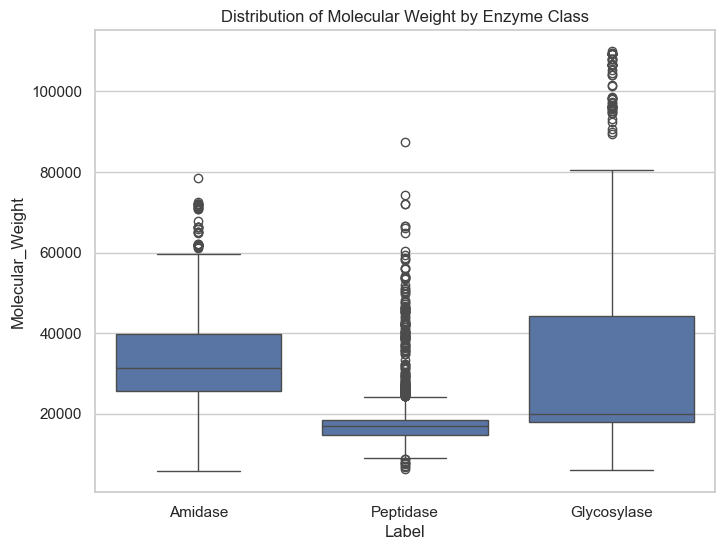

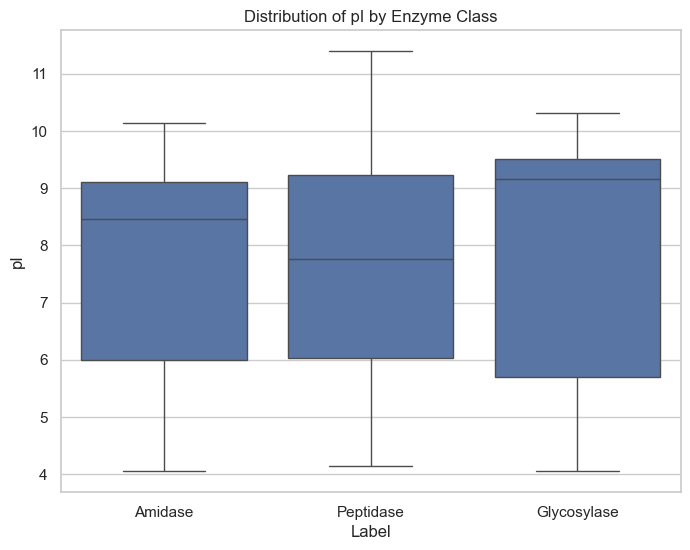

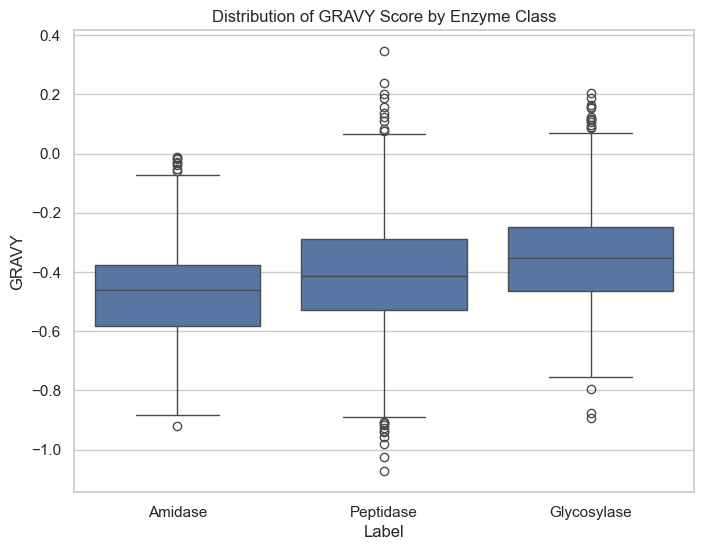

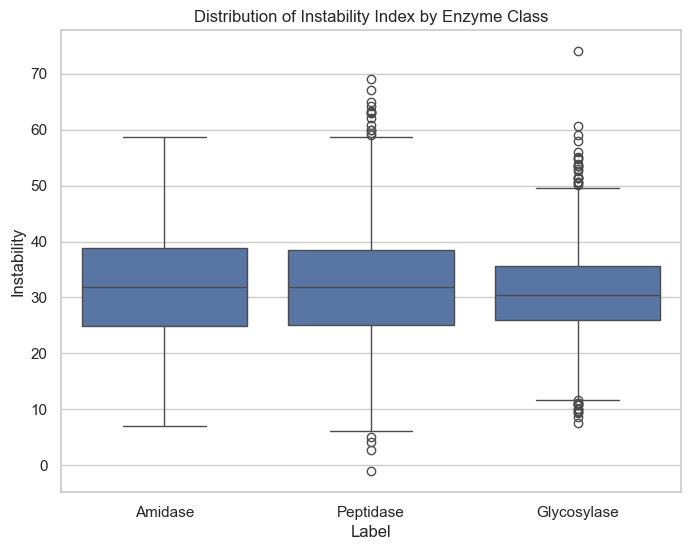

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# boxplot for Molecular Weight
plt.figure(figsize=(8, 6))
sns.boxplot(data=master_df, x='Label', y='Molecular_Weight')
plt.title('Distribution of Molecular Weight by Enzyme Class')
plt.show()

# boxplot for pI
plt.figure(figsize=(8, 6))
sns.boxplot(data=master_df, x='Label', y='pI')
plt.title('Distribution of pI by Enzyme Class')
plt.show()

# boxplot for GRAVY
plt.figure(figsize=(8, 6))
sns.boxplot(data=master_df, x='Label', y='GRAVY')
plt.title('Distribution of GRAVY Score by Enzyme Class')
plt.show()

# boxplot for Instability
plt.figure(figsize=(8, 6))
sns.boxplot(data=master_df, x='Label', y='Instability')
plt.title('Distribution of Instability Index by Enzyme Class')
plt.show()

For Instability, pI, and GRAVY, there is a massive overlap in the boxes. The medians are almost identical, and the whiskers cover the exact same ranges. This indicates the physical similarity among all the protein sequences, so if we use a classical algorithm to separate the enzymes based on these characteristics, it's probably going to fail.

As for molecular weight, however, this is the only feature wherein there is a structural difference. Peptidases are shown to be much lighter (wherein it's tightly clustered under 20,000 Daltons), while Amidases and Glycosylases are heavier. However, there is still a big overlap between Amidases and Glycosylases in the 20k-40k range.

This shows that classical models may have difficulty in clearly defining and definitively separating an Amidase from a Glycosylase, as they weigh the same, have the same charge, and interact with water in the exact same way. We hypothesize that, once we generate high-dimensional 3D embeddings of the amino acids and get their structural context, we can tell them apart. This is exactly what we'll be using the ESM-2 transformer for.

Next, let's create a histogram showing the Sequence Length distribution, overlaid for all three classes.


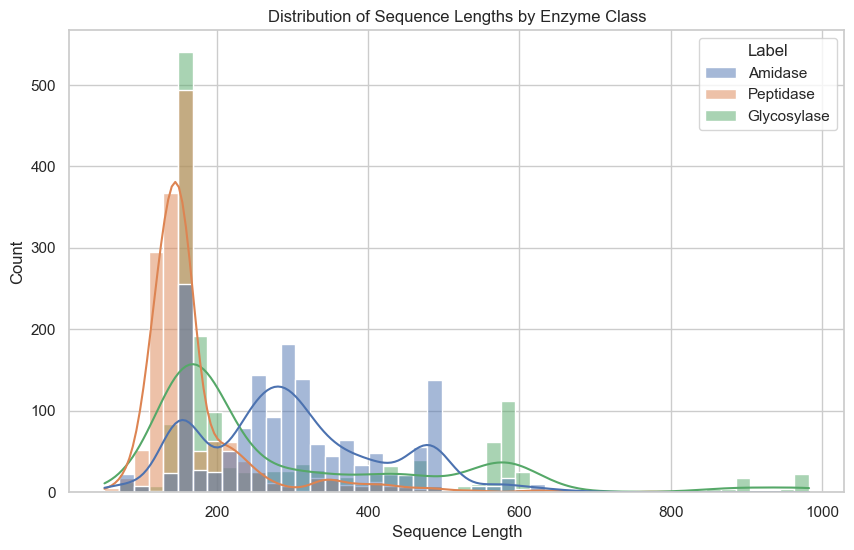

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(data=master_df, x='Sequence Length', hue='Label', kde=True)
plt.title('Distribution of Sequence Lengths by Enzyme Class')
plt.show()

Looking at this histogram, there is a tight distribution between 100 and 200 amino acids. The distribution of Peptidase is more consistent, while Glycosylase is more spread out. On the other hand, the Amidase distribution has three distinct "humps" roughly around the 150, 300, and 500 sequence length marks. In computational biology, multimodality usually indicates sub-families or multi-domain proteins. We are likely looking at simpler Amidases on the left humps, and more complex multi-domain Amidases on the right.

While Peptidases look to be shorter on average, around that 150-length mark where all three colors intersect show us that if a sequence is around 150 amino acids long, its length alone isn't enough to determine what class it is.

## **Setting the Classical Baseline before ESM-2**

Given the data we have so far, before we jump into getting embeddings from ESM-2, let's first try classifying using classical models (Random Forest, XGBoost, MLP). Let's also look at simpler models like KNN, Naive Bayes, and Logistic Regression to see how they stack up.

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# 1. Isolate X and y
features = ['Molecular_Weight', 'pI', 'GRAVY', 'Instability']
X = master_df[features]
y_raw = master_df['Label']

# 2. Encode string labels
le = LabelEncoder()
y = le.fit_transform(y_raw)

# 3. Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Scale the Data
# We strictly fit the scaler ONLY on the training data to prevent data leakage.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Initialize Models
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='mlogloss'),
    "MLP (Neural Network)": MLPClassifier(random_state=42, max_iter=1000),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000)
}

# 6. Execute Matrix
results_list = []

for name, model in models.items():
    # Fit and predict on the SCALED data
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    
    # zero_division=0 silences the warning if a model still fails completely
    report = classification_report(y_test, preds, target_names=le.classes_, output_dict=True, zero_division=0)
    
    results_list.append({
        "Model": name,
        "Overall Accuracy": round(report['accuracy'], 4),
        "Amidase F1": round(report['Amidase']['f1-score'], 4),
        "Glycosylase F1": round(report['Glycosylase']['f1-score'], 4),
        "Peptidase F1": round(report['Peptidase']['f1-score'], 4)
    })

# 7. Results
results_df = pd.DataFrame(results_list).sort_values(by="Overall Accuracy", ascending=False)
results_df

,Model,Overall Accuracy,Amidase F1,Glycosylase F1,Peptidase F1
0,Random Forest,0.8241,0.8712,0.8007,0.7988
1,XGBoost,0.8136,0.8541,0.7942,0.7913
2,MLP (Neural Network),0.7874,0.8191,0.7573,0.7833
3,K-Nearest Neighbors,0.7665,0.8296,0.7270,0.7391
4,Naive Bayes,0.5728,0.6427,0.3476,0.6396
5,Logistic Regression,0.5665,0.5106,0.4951,0.6703


We can see that the simpler models, especially Logistic Regression, perform much worse compared to the more complex classical models. Right now, the highest accuracy we have is **82.41%**, so we'll try to push that value to the high 90s with the ESM-2 embeddings.

## **Data Preprocessing for Deep Feature Extraction**

We'll first setup PyTorch and ESM-2. Since we're utilizing an Apple Silicon device, we can utilize Metal Performance Shaders (MPS) to accelerate PyTorch tasks. 

In [10]:
import torch
print("MPS Built:", torch.backends.mps.is_built())
print("MPS Available:", torch.backends.mps.is_available())

# test
if torch.backends.mps.is_available():
    device = torch.device("mps")
    x = torch.ones(1, device=device)
    print("Successful tensor generation on:", x.device)
else:
    print("WARNING: GPU not engaged. PyTorch will default to CPU.")

MPS Built: True
MPS Available: True
Successful tensor generation on: mps:0


Let's initialize the model.

In [ ]:
# If you run into an SSL error, for MacOS, run this command in your terminal: open "/Applications/Python 3.14/Install Certificates.command"
# If this part doesn't stop loading, restart and clear output in the kernel.

import esm
import torch

print("Log 1: Imports successful. Attempting to load model from disk/web...")
# If stuck here, run this "rm -rf ~/.cache/torch/hub/checkpoints/esm2_t30_150M_UR50D.pt" in terminal
# Load ESM-2 Model (took this from the fair-esm documentation)
model, alphabet = esm.pretrained.esm2_t30_150M_UR50D()

print("Log 2: Model loaded into CPU RAM. Attempting transfer to MPS GPU...")

device = torch.device("mps")
model.to(device) # moving the device to the model

print("Log 3: Model successfully transferred to GPU. Setting eval mode...")

batch_converter = alphabet.get_batch_converter()
model.eval()  # disables dropout for deterministic results

print(f"Log 4: Execution Complete. Hardware locked to: {next(model.parameters()).device}")

Log 1: Imports successful. Attempting to load model from disk/web...
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t30_150M_UR50D.pt" to /Users/navi/.cache/torch/hub/checkpoints/esm2_t30_150M_UR50D.pt
